In [1]:
#Библиотеки
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    average_precision_score,
    precision_recall_curve,
    ConfusionMatrixDisplay)
from sklearn.metrics import confusion_matrix
from sklearn.inspection import permutation_importance
from sklearn.svm import SVC

In [2]:
#Загрузим датасет
df = pd.read_csv('Bank Customer Churn Prediction.csv')
#Выведем размер датасета, кол-во дубликатов строк и строк с пропусками
print(f'Размер таблицы до подготовки данных:{df.shape}')
print(f'Количество дубликатов до подготовки = {df.duplicated().sum()}')
print(f'Количество строк с пропусками до подготовки = {df.isna().any(axis=1).sum()}') 

#Проверим фичи - выведем названия, кол-во и % пропусков, типы данных
info = pd.DataFrame({"missing":(df.isna().sum()),
                     "missing_%": (df.isna().mean() * 100).round(2),
                     "dtype": df.dtypes})
print(info.sort_values("missing_%", ascending=False))

# выведем уникальные значения категориальных столбцов и таргета
categorical_columns = ["country","gender"]
for col in categorical_columns:
    print(f"\nУникальные {col}:")
    print(df[col].unique().tolist())

print(f"\nУникальные таргеты:")
print(df["churn"].unique().tolist())

#смотрим распределение таргета
print(df["churn"].value_counts()) 

df.head(5)

Размер таблицы до подготовки данных:(10000, 12)
Количество дубликатов до подготовки = 0
Количество строк с пропусками до подготовки = 0
                  missing  missing_%    dtype
customer_id             0        0.0    int64
credit_score            0        0.0    int64
country                 0        0.0      str
gender                  0        0.0      str
age                     0        0.0    int64
tenure                  0        0.0    int64
balance                 0        0.0  float64
products_number         0        0.0    int64
credit_card             0        0.0    int64
active_member           0        0.0    int64
estimated_salary        0        0.0  float64
churn                   0        0.0    int64

Уникальные country:
['France', 'Spain', 'Germany']

Уникальные gender:
['Female', 'Male']

Уникальные таргеты:
[1, 0]
churn
0    7963
1    2037
Name: count, dtype: int64


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Таким образом мы видим, что
- размер датасета 10к строк, 12 столбцов
- пропуски отсутствуют
- дубликаты отсутствуют
- таргет загружен корректно (integer, 1/0)
- 2 фичи типа string (country, gender), остальные - числовые float, integer
- фича country содержит 3 уникальных значения (потенциально можем использовать OHE, т.к. небольшое кол-во уникальных значений)
- фича gender содержит 2 уникальных значения (потенциально можем использовать OHE, т.к. небольшое кол-во уникальных значений)
- распределение таргета (20% - 1/80% - 0), то есть существует дисбаланс классов

In [3]:
df.describe() #смотрим статистику числовых фичей

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


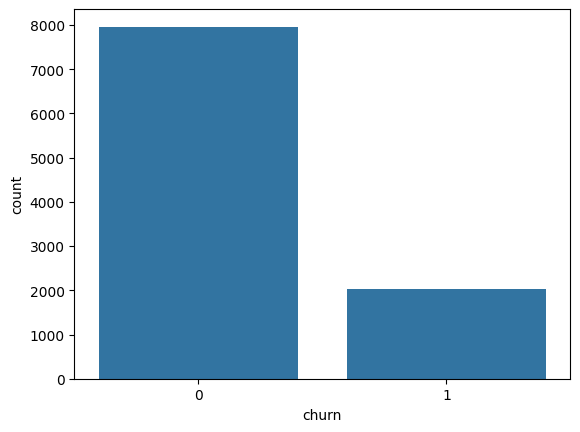

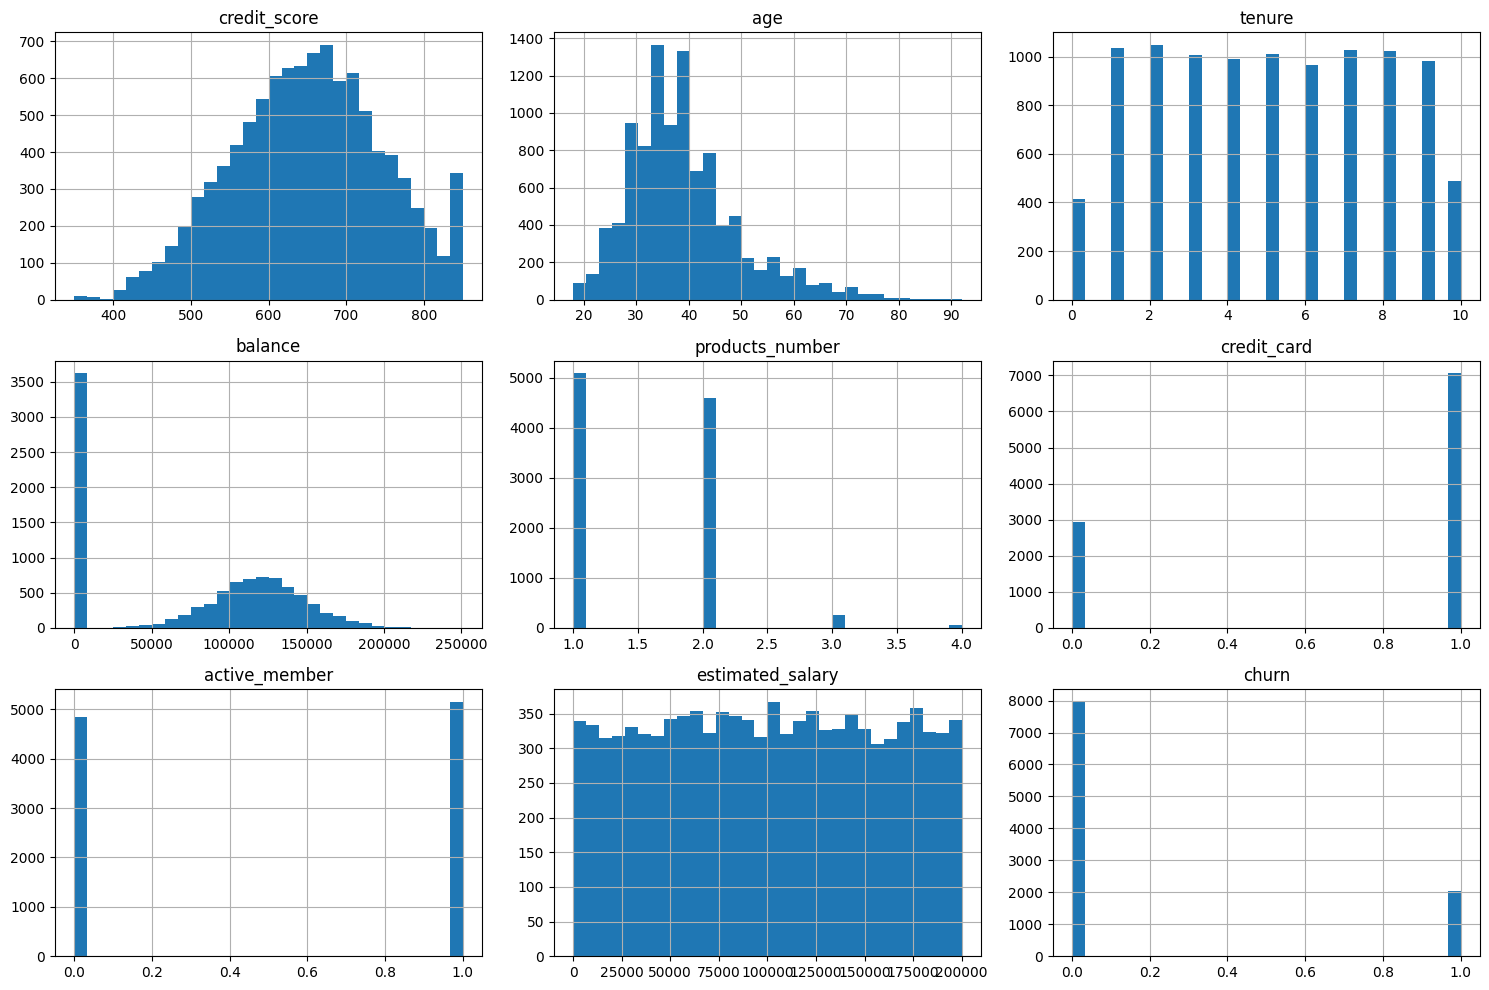

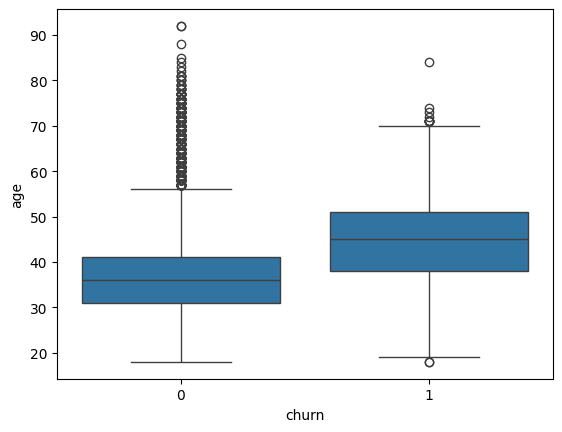

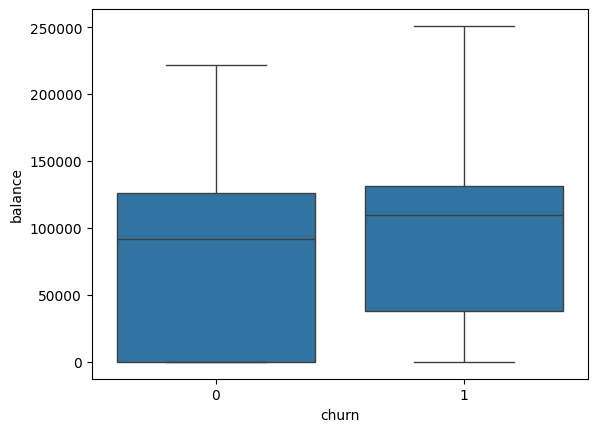

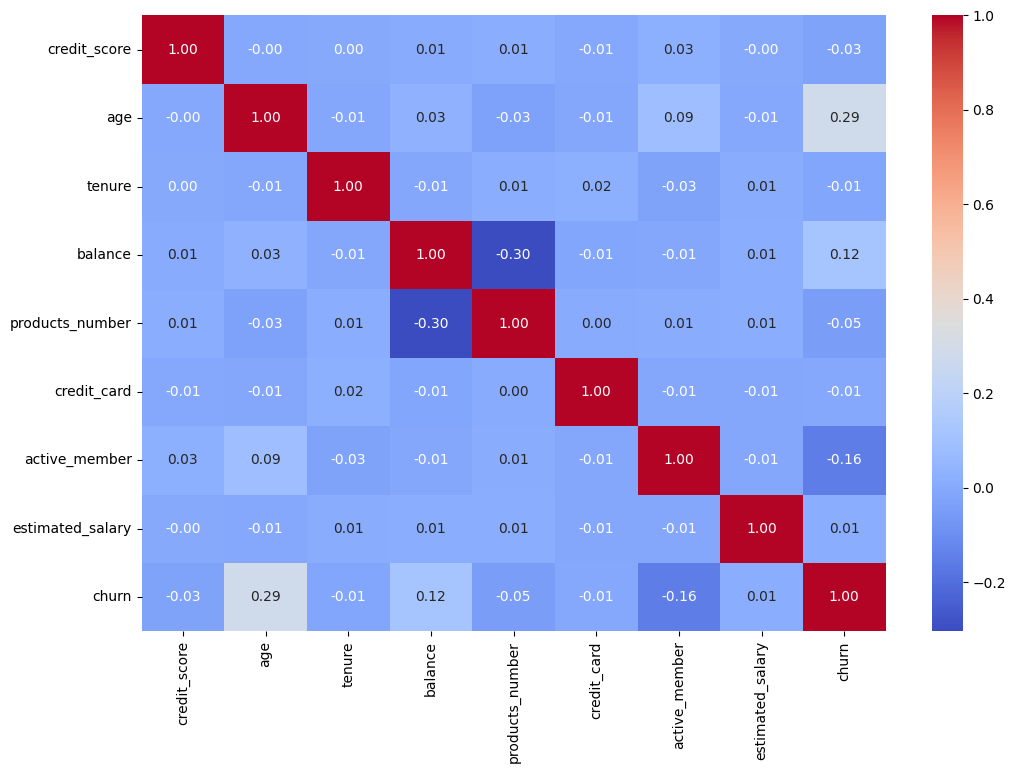

In [4]:
#график распределения целевой переменной
sns.countplot(x='churn', data=df)
plt.show()

#удаляем столбец, который является техническим и не несет полезной информации - 'customer_id'
df = df.drop(columns=['customer_id'])

#гистограммы для числовых признаков
df.hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

#boxplot для возраста и баланса относительно churn
sns.boxplot(x='churn', y='age', data=df)
plt.show()

sns.boxplot(x='churn', y='balance', data=df)
plt.show()

#тепловая карта корреляции для числовых признаков 
plt.figure(figsize=(12, 8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f')

plt.show()

Таким образом, мы видим, что
- столбец "customer_id" нам не нужен, т.к. является техническим и не несет полезной информации для модели
- медианный возраст клиентов, ушедших из банка выше, чем медианный возраст клиентов, оставшихся в банке
- медианный баланс клиентов, ушедших из банка, выше, чем у клиентов, оставшихся в банке 
- наибольшую корреляцию с таргетом имеет столбец возраста. Можем сделать предварительное предположение о том, что банк не клиентоориентирован на людей, старшего возраста. То есть возраст сильнее всего коррелирует с оттоком клиентов. На втором месте по корреляции идет признак активности клиента.
- также мы видим максимальную (из возможных) отрицательную корреляцию между фичами баланс и число продуктов.

Accuracy:  0.8080
Precision: 0.5891
Recall:    0.1867
F1-score:  0.2836
ROC AUC:   0.7748
PR AUC:    0.4788


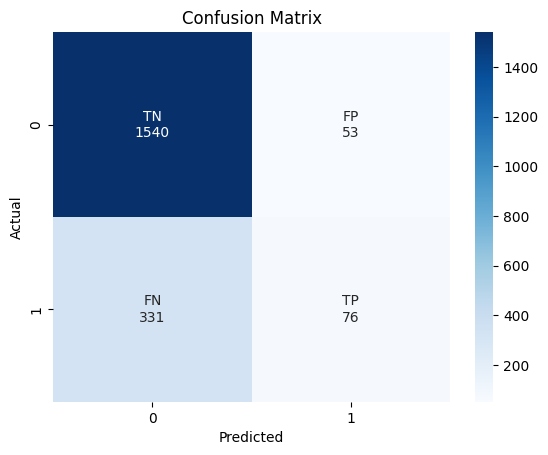

In [5]:
#Разделите данные на train (80%) и test (20%) с stratify по целевой переменной
X = df.drop(columns=["churn"])     # исходные фичи
y = df["churn"]     # целевая переменная (0/1)

RANDOM_STATE = 42 #фиксируем случайность

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

#Собираем препроцессор для масштабирования и OHE
numerical_columns = ["credit_score", "age", "tenure", "balance", "products_number", "estimated_salary"]
binary_columns = ["credit_card", "active_member"]
categorical_columns = ["country", "gender"]
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns),
    ("num", StandardScaler(), numerical_columns),
    ("bin","passthrough", binary_columns)])

#Собираем пайплайн
baseline_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE))])

#Обучаем пайплайн, считаем предсказания их вероятности
baseline_pipeline.fit(X_train, y_train)
y_pred = baseline_pipeline.predict(X_test)
y_proba = baseline_pipeline.predict_proba(X_test)[:, 1]

#Считаем метрики
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC AUC:   {roc_auc:.4f}")
print(f"PR AUC:    {pr_auc:.4f}")

#Выводим матрицу ошибок
cm = confusion_matrix(y_test, y_pred)
labels = [
    [f"TN\n{cm[0, 0]}", f"FP\n{cm[0, 1]}"],
    [f"FN\n{cm[1, 0]}", f"TP\n{cm[1, 1]}"]]
sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Мы получили основные метрики оценки модели для классификации. Для данной задачи я бы за основную взял Recall, так как самое важное для нас - полнота, то есть выявить всех людей, кто потенциально может уйти из банка, чтобы провести с ними те или иные мероприятия. Также необходимо помнить, что бизнес может нам сообщить об определенной себестоимости данных мероприятий, в связи с чем уже логичнее смотреть также на другие метрики, которые не только говорят о полноте, но и о точности (например среднее гармоническое между Precision и Recall - F1 score). Воспользуемся методом permutation_importance для оценки важности фичей. За основу возьмем recall

            feature  importance
3               age    0.082310
1           country    0.043243
8     active_member    0.026044
5           balance    0.007125
6   products_number    0.005897
2            gender    0.002457
4            tenure    0.001474
7       credit_card   -0.003440
9  estimated_salary   -0.005405
0      credit_score   -0.007862


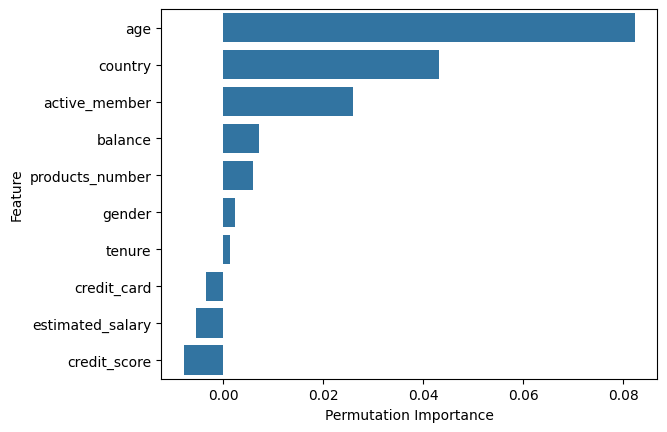

In [6]:
#Применяем permutation_importance
result = permutation_importance(
    baseline_pipeline,
    X_test,
    y_test,
    scoring='recall',
    n_repeats=10,
    random_state=RANDOM_STATE)

#Формируем таблицу-отчет
importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': result.importances_mean})
#Сортируем по важности
importance_df = importance_df.sort_values(
    'importance',
    ascending=False)

print(importance_df)

#Строим график
sns.barplot(
    data=importance_df,
    x='importance',
    y='feature')

plt.xlabel('Permutation Importance')
plt.ylabel('Feature')
plt.show()

Таким образом, обучив модель логистической регрессии на нашем датасете и оценив данную модель по метрикам, а затем получив важность каждого признака, взяв за основу метрику recall, мы можем увидеть, что 
1) наиболее важным является признак возраст (что мы изначально показали на тепловой карте корреляции). 
2) на второе место по важности вышел признак страна. В матрице корреляции он отсутствовал в связи с тем, что он на тот момент еще не был закодирован через OHE. 
3) на третьем месте по важности идет столбец активность клиента, что тоже было показано на тепловой карте.

Также мы видим, что результаты метрик оценки качества модели классификации  
Accuracy:  0.8080 - 80,8% данных модель определила верно (TP и TN)  
Precision: 0.5891 - 58,91% точность (из всех людей, которые модель назвала положительными (TP+FP) реально положительных (TP) 58,91%)  
Recall:    0.1867 - 18,67% полнота (из всех реально положительных людей (TP+FN) модель правильно определила (TP) 18,67%)  
F1-score:  0.2836 - среднее гармоническое между Precision и Recall 28,36%  
ROC AUC:   0.7748   
PR AUC:    0.4788  
Я бы оценил качество данной модели как довольно низкое, и применял бы ее в качестве baseline, сравнивая также полиномиальную генерацию фичей и метод SVM

In [7]:
#Создадим функцию для задавания степени полинома
def make_poly_pipeline(degree):
    
    num_pipeline = Pipeline([
        ("poly", PolynomialFeatures(
            degree=degree,
            include_bias=False)),
        ("scaler", StandardScaler())])
    
    poly_preprocessor = ColumnTransformer([
        ("num", num_pipeline, numerical_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns),
        ("bin", "passthrough", binary_columns)])
    
    return Pipeline([
        ("preprocessor", poly_preprocessor),
        ("model", LogisticRegression(
            max_iter=3000,
            random_state=RANDOM_STATE))])

poly_2 = make_poly_pipeline(2)
poly_3 = make_poly_pipeline(3)
poly_4 = make_poly_pipeline(4)
poly_5 = make_poly_pipeline(5)


#Метод опорных векторов с ядром радиальная базисная функция Гаусса
svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(
        kernel="rbf",
        probability=True,
        random_state=RANDOM_STATE))])

#Собираем модели
models = {
    "Logistic Regression": baseline_pipeline,
    "Polynomial degree 2": poly_2,
    "Polynomial degree 3": poly_3,
    "Polynomial degree 4": poly_4,
    "Polynomial degree 5": poly_5,
    "SVM": svm_pipeline}

#Обучаем модели и вычисляем метрики
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_proba),
        "PR AUC": average_precision_score(y_test, y_proba)})

results_df = pd.DataFrame(results)
results_df

c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC
0,Logistic Regression,0.8080,0.589147,0.186732,0.283582,0.774801,0.478790
1,Polynomial degree 2,0.8570,0.766520,0.427518,0.548896,0.852187,0.682988
2,Polynomial degree 3,0.8590,0.759336,0.449631,0.564815,0.856359,0.682836
3,Polynomial degree 4,0.8570,0.742972,0.454545,0.564024,0.857320,0.685310
4,Polynomial degree 5,0.8585,0.746032,0.461916,0.570561,0.856319,0.685601
5,SVM,0.8635,0.848958,0.400491,0.544240,0.831750,0.690020


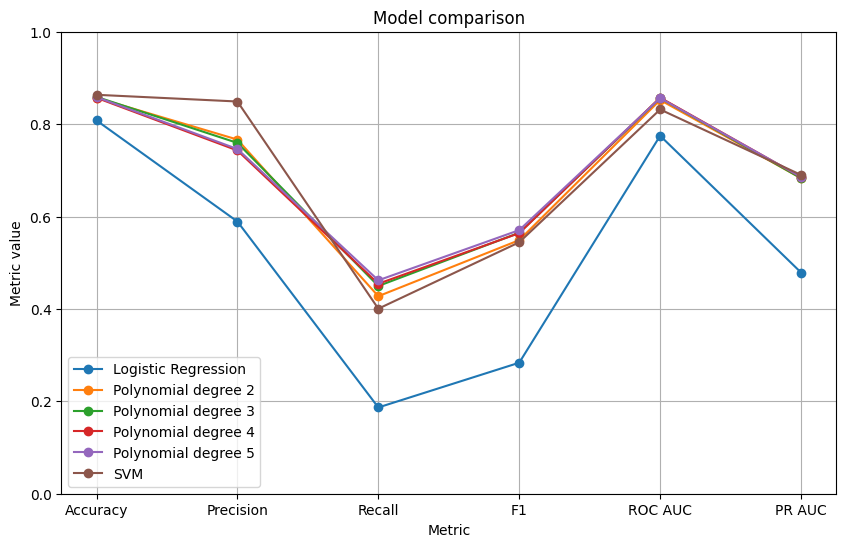

In [8]:
#Визуализируем значения метрик оценки качества для наших моделей
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC AUC",
    "PR AUC"]

plt.figure(figsize=(10, 6))
for _, row in results_df.iterrows():
    plt.plot(
        metrics,
        row[metrics],
        marker="o",
        label=row["Model"])

plt.ylim(0, 1)
plt.ylabel("Metric value")
plt.xlabel("Metric")
plt.title("Model comparison")
plt.legend()
plt.grid()
plt.show()

Теперь мы можем сделать вывод о том, что оптимальный результат показала модель SVM, т.к. по сравнению с полиномиальной регрессией она имеет наибольшее значение Precision при относительно одинаковых значениях Accuracy, PR AUC и небольшом ухудшении ROC AUC, F1, Recall 

Однако необходимо понимать, что конечный выбор будет сильно зависеть от условий бизнеса. Например, если у нас отсутствует себестоимость мероприятий, направленных на клиентов, которые потенциально могут уйти из банка (просто им будет направляться иная реклама), то имеет смысл сделать выбор в пользу модели с наибольшей полнотой (Recall), то есть в данном случае - линейный классификатор с полиномиальным преобразованием признаков 5 степени, однако необходимо помнить про риск переобучения

Найдем зависимость Precision и Recall для различных порогов (при методе SVM), чтобы можно было задавать определенное условие (например, бизнесу нужно определять минимум 80% всех уходов). Тогда мы сможем определить порог и сказать о точности данной модели (Precision)

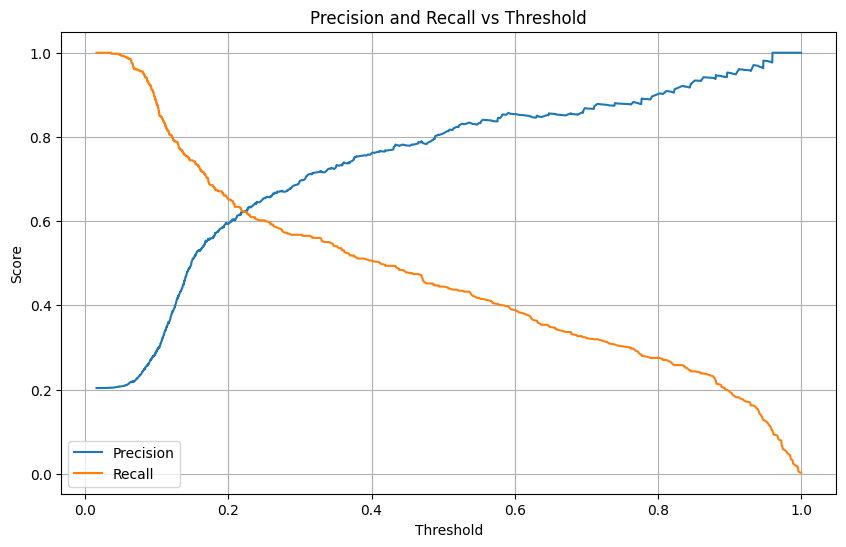

In [9]:
y_proba = svm_pipeline.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_proba)

plt.figure(figsize=(10, 6))

plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Threshold")
plt.legend()
plt.grid()

plt.show()

Сделаю для себя то же самое, только с кросс-валидацией (ниже)

In [10]:
# Стратифицированная кросс-валидация
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE)

models = {
    "Logistic Regression": baseline_pipeline,
    "Polynomial degree 2": poly_2,
    "Polynomial degree 3": poly_3,
    "Polynomial degree 4": poly_4,
    "Polynomial degree 5": poly_5,
    "SVM RBF": svm_pipeline}

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"}

# Запускаем кросс-валидацию для каждой модели:
cv_results = []
for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1)

    cv_results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC AUC": scores["test_roc_auc"].mean(),
        "PR AUC": scores["test_pr_auc"].mean()})

cv_results_df = pd.DataFrame(cv_results)

cv_results_df

,Model,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC
0,Logistic Regression,0.810375,0.596080,0.213497,0.314058,0.762840,0.468763
1,Polynomial degree 2,0.853000,0.753324,0.413497,0.533776,0.846776,0.665377
2,Polynomial degree 3,0.853750,0.733952,0.441718,0.551097,0.851834,0.672668
3,Polynomial degree 4,0.852875,0.721103,0.452147,0.555470,0.852897,0.673306
4,Polynomial degree 5,0.853375,0.720420,0.457669,0.559352,0.851018,0.670572
5,SVM RBF,0.855250,0.800409,0.385276,0.519920,0.831641,0.666740


Выведем график зависимости Precision и Recall для различных порогов (при полиномиальном преобразовании признаков 5 степени)

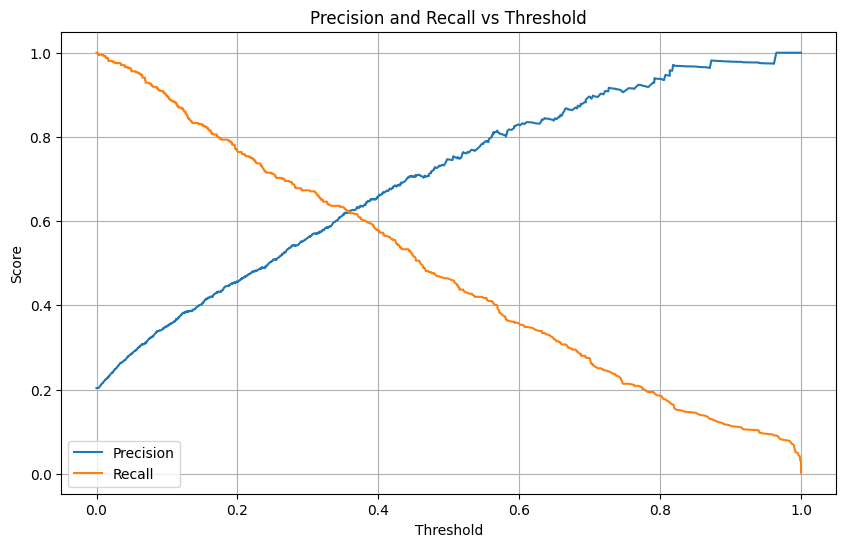

In [11]:
y_proba = poly_5.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_proba)

plt.figure(figsize=(10, 6))

plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Threshold")
plt.legend()
plt.grid()

plt.show()